In [1]:
import pandas as pd
import numpy as np

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 
           'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

df = pd.read_csv(url, names=columns)


In [2]:
df.replace('?', np.nan, inplace=True)
df['ca'] = pd.to_numeric(df['ca'])
df['thal'] = pd.to_numeric(df['thal'])

def categorize_target(val):
    if val == 0:
        return 1  # Healthy
    elif val == 1 or val == 2:
        return 2  # At Risk
    else:
        return 3  # Disease Present

df['target'] = df['target'].apply(categorize_target)

from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values=np.nan, strategy='median')
df[['ca', 'thal']] = imputer.fit_transform(df[['ca', 'thal']])

from sklearn.preprocessing import StandardScaler
X = df.drop('target', axis=1)
y = df['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data preprocessing, median imputation, and scaling complete.")

Data preprocessing, median imputation, and scaling complete.


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_accuracy = dt_model.score(X_test, y_test)

from sklearn.svm import SVC

svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)
svm_accuracy = svm_model.score(X_test, y_test)

print("--- MODEL ACCURACY RESULTS ---")
print(f"Decision Tree Accuracy: {dt_accuracy * 100:.2f}%")
print(f"SVM Accuracy: {svm_accuracy * 100:.2f}%")

--- MODEL ACCURACY RESULTS ---
Decision Tree Accuracy: 55.74%
SVM Accuracy: 68.85%


--- DECISION TREE CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           1       0.68      0.79      0.73        29
           2       0.41      0.43      0.42        21
           3       0.40      0.18      0.25        11

    accuracy                           0.56        61
   macro avg       0.50      0.47      0.47        61
weighted avg       0.53      0.56      0.54        61


--- SVM CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           1       0.81      0.90      0.85        29
           2       0.55      0.57      0.56        21
           3       0.57      0.36      0.44        11

    accuracy                           0.69        61
   macro avg       0.64      0.61      0.62        61
weighted avg       0.68      0.69      0.68        61



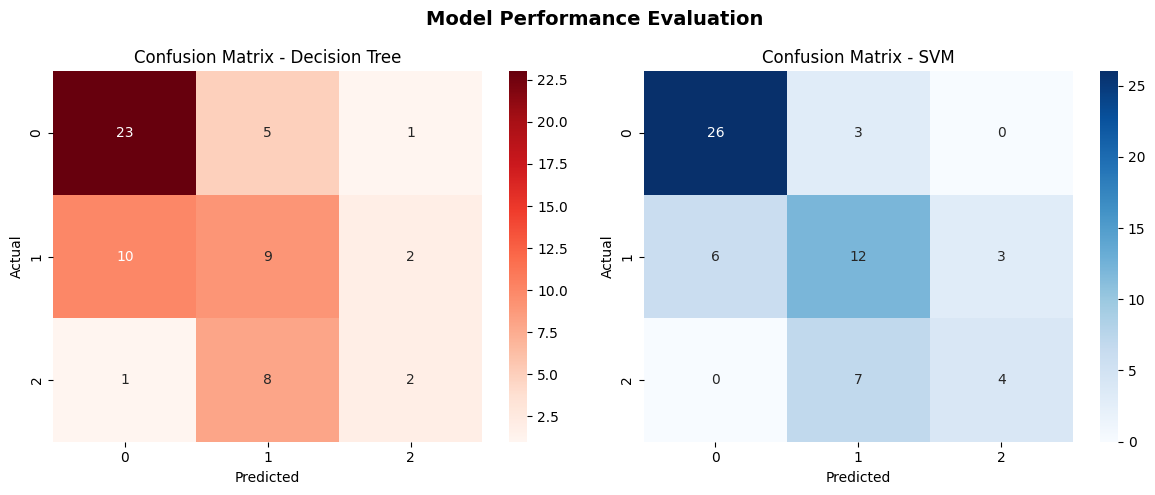

In [4]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

dt_preds = dt_model.predict(X_test)
svm_preds = svm_model.predict(X_test)

print("--- DECISION TREE CLASSIFICATION REPORT ---")
print(classification_report(y_test, dt_preds))

print("\n--- SVM CLASSIFICATION REPORT ---")
print(classification_report(y_test, svm_preds))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Model Performance Evaluation', fontsize=14, fontweight='bold')

sns.heatmap(confusion_matrix(y_test, dt_preds), annot=True, fmt='d', cmap='Reds', ax=axes[0])
axes[0].set_title('Confusion Matrix - Decision Tree')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

sns.heatmap(confusion_matrix(y_test, svm_preds), annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Confusion Matrix - SVM')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

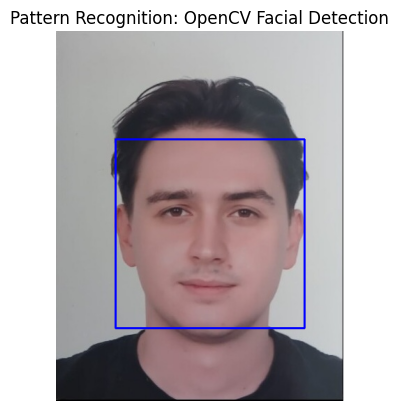

In [5]:
import cv2
import matplotlib.pyplot as plt


face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

image_path = 'test.jpg'
img = cv2.imread(image_path)

if img is None:
    print("Error: Image file error")
else:
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    faces = face_cascade.detectMultiScale(gray, 1.1, 4)
    
    for (x, y, w, h) in faces:
        cv2.rectangle(img, (x, y), (x+w, y+h), (255, 0, 0), 2)
        
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title("Pattern Recognition: OpenCV Facial Detection")
    plt.show()